Data Exploration

In [18]:
# Importing Necessary Libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import scipy.stats as stats

In [9]:
# Data Set Overview

df = pd.read_csv('../data/raw/kc_house_data.csv')

df.head()
df.info()
df.describe()
df.shape
df.columns


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='object')

<Axes: >

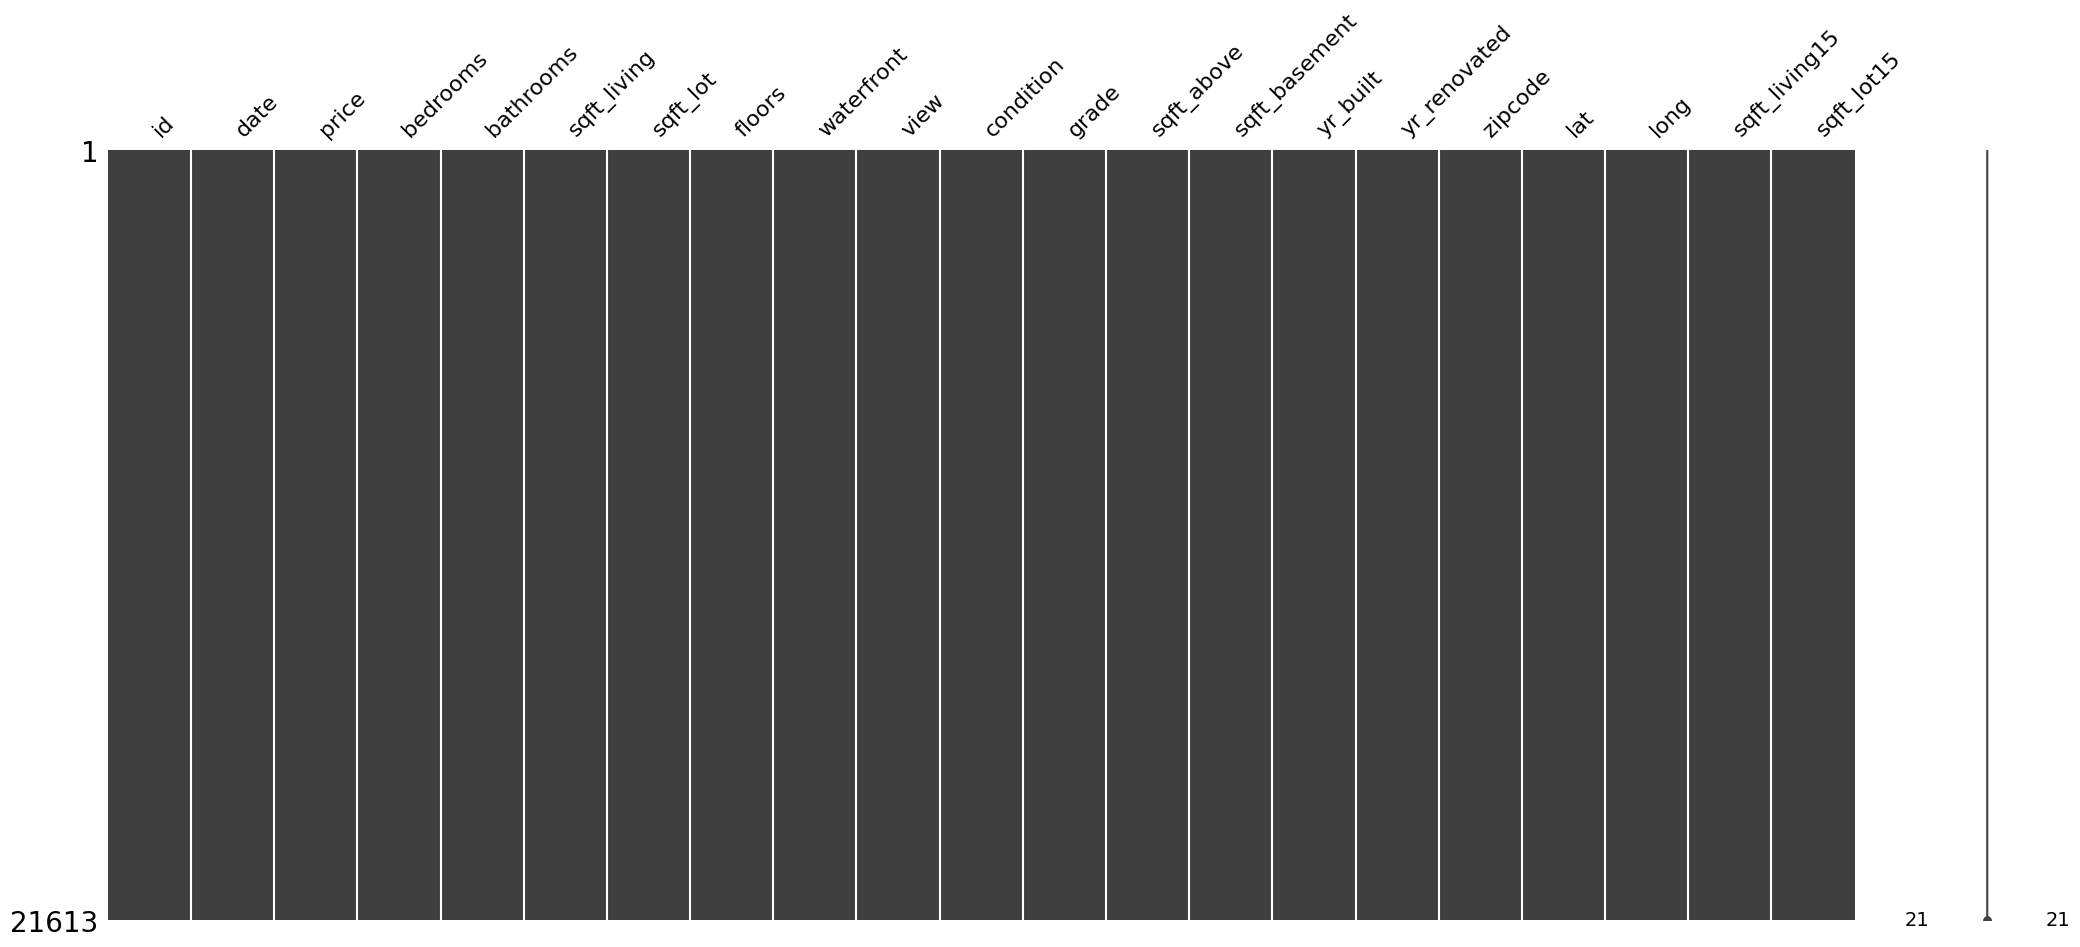

In [19]:
# Missing Values Check

df.isnull().sum()
df.isnull().mean() * 100

msno.matrix(df)

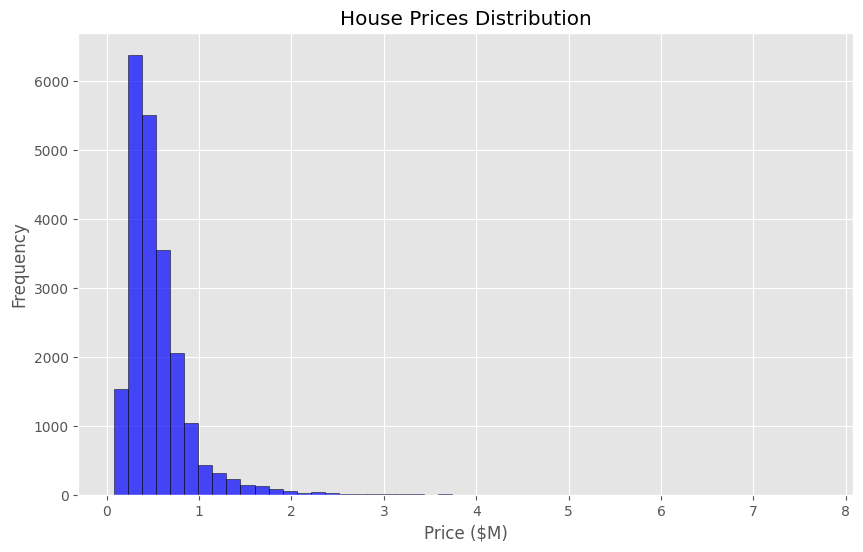

Mean Price: $540,088.14
Median Price: $450,000.00
Mode Price: $350,000.00
Price - Minimum: $75,000.00
Price - Maximum: $7,700,000.00
Price - Range: $7,625,000.00
Price - Standard Deviation: $367,127.20
Price - Skewness: 4.02
Lower Bound (1 SD): $172,960.95 and Upper Bound (1 SD): $907,215.34
Percentage of houses within 1 standard deviation: 88.90%


In [60]:
# Target Variable - Sale Price Analysis

plt.figure(figsize=(10, 6))
plt.hist(df['price']/1000000, bins=50, color='blue', edgecolor='black', alpha=0.7)
plt.title('House Prices Distribution')
plt.xlabel('Price ($M)')
plt.ylabel('Frequency')
plt.show()

df['price'].describe()
print(f'Mean Price: ${df['price'].mean():,.2f}')
print(f'Median Price: ${df['price'].median():,.2f}')
print(f'Mode Price: ${df['price'].mode()[0]:,.2f}')
print(f'Price - Minimum: ${df['price'].min():,.2f}')
print(f'Price - Maximum: ${df['price'].max():,.2f}')
print(f'Price - Range: ${df['price'].max() - df['price'].min():,.2f}')
print(f'Price - Standard Deviation: ${df['price'].std():,.2f}')
print(f'Price - Skewness: {df['price'].skew():.2f}')

mean_price = df['price'].mean()
std_price = df['price'].std()

lower_bound = mean_price - 1 * std_price
upper_bound = mean_price + 1 * std_price

within_1_std = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]
percentage_within_1_std = (len(within_1_std) / len(df)) * 100
print(f'Lower Bound (1 SD): ${lower_bound:,.2f} and Upper Bound (1 SD): ${upper_bound:,.2f}')
print(f'Percentage of houses within 1 standard deviation: {percentage_within_1_std:.2f}%')


###  Target Variable Analysis - What I found with data:

- Mean > Median > Mode & the plot distribution shows it is *right skewed*.  
- Standard Deviation:
    - Huge variation
    - Almost 89% within the 1 SD. So very few houses below $173K and Luxury houses above $907K forming a long right tail.
- Skewness:
    - Extremely right-skewed. Multi-million dollar houses are extreme outlier pulling ditribution. 


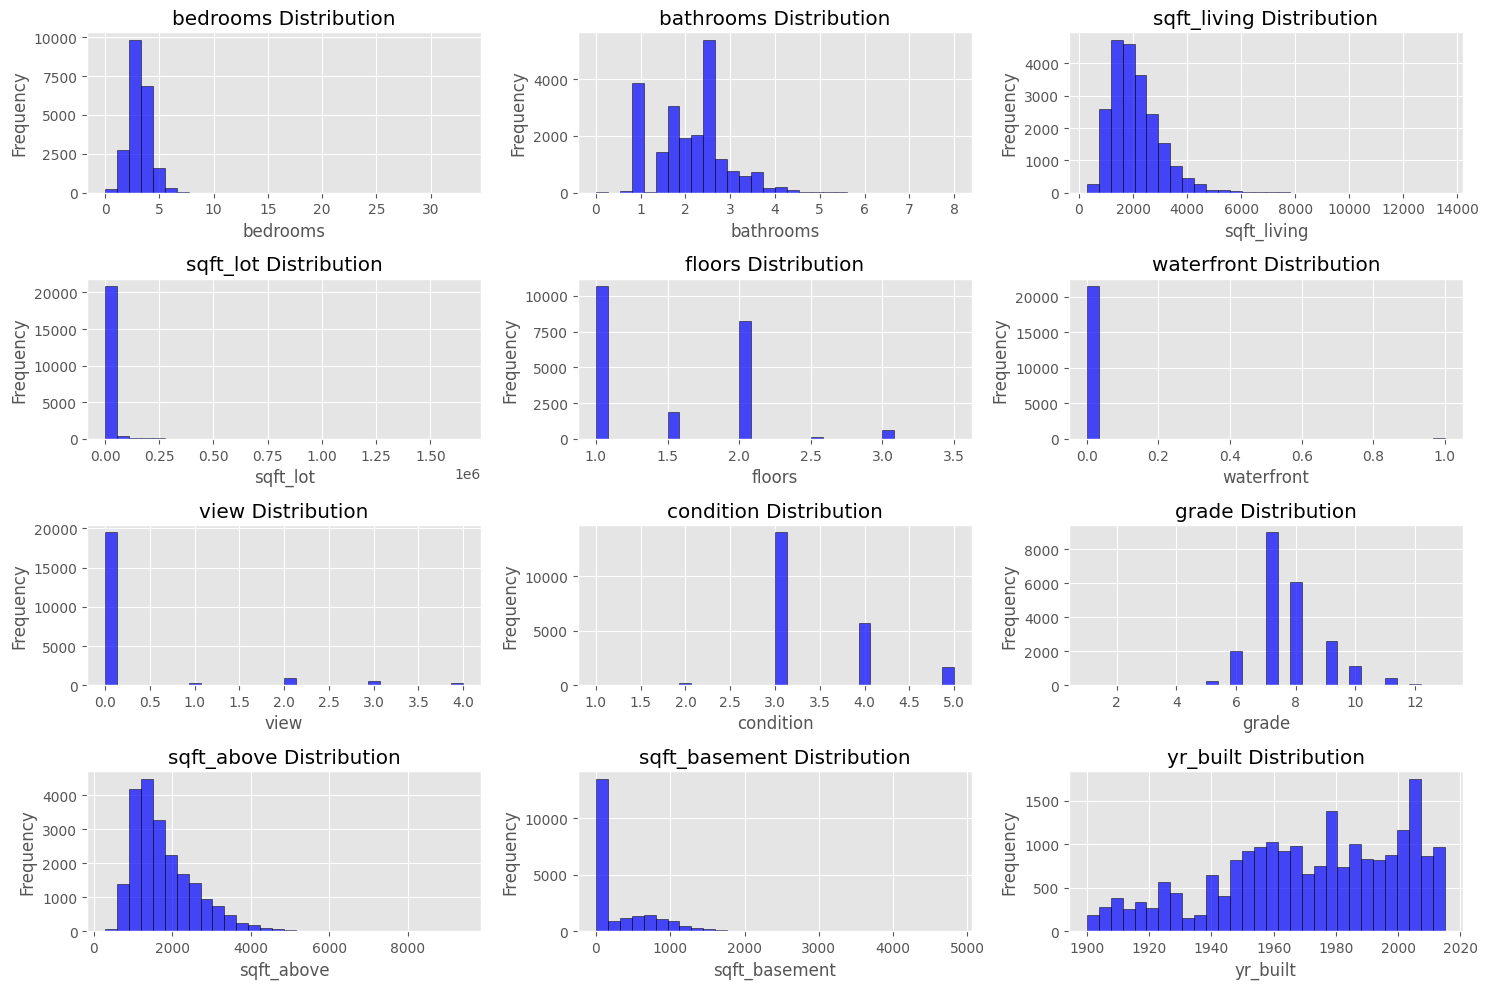

In [53]:
features = ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built']

fig, axes = plt.subplots(4, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feature in enumerate(features):
    axes[i].hist(df[feature], bins=30, color='b', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'{feature} Distribution')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()